In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_path = "/content/drive/MyDrive/CNN_ACCIDENT_DATASET/data"

In [5]:
train_path = "/content/drive/MyDrive/CNN_ACCIDENT_DATASET/data/train"
test_path = "/content/drive/MyDrive/CNN_ACCIDENT_DATASET/data/test"
val_path = "/content/drive/MyDrive/CNN_ACCIDENT_DATASET/data/val"

**### 1.	 EDA and  visualizations.**

In [6]:
from typing_extensions import TypeForm
# importing all necessaty libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [7]:
# defining data set path
base_path ="/content/drive/MyDrive/CNN_ACCIDENT_DATASET/data"

train_path= os.path.join(base_path,"train")
test_path=os.path.join(base_path,"test")
val_path=os.path.join(base_path ,"val")

In [8]:
# check data Structure or classes
print("Train_classes",os.listdir(train_path))
print("Test_classes",os.listdir(test_path))
print("val_classes",os.listdir(val_path))

Train_classes ['Accident', 'Non Accident']
Test_classes ['Accident', 'Non Accident']
val_classes ['Accident', 'Non Accident']


In [9]:
# Counting images for each class to detect imbalace to get basic info

train_accident=len(os.listdir(os.path.join(train_path,"Accident")))
train_no_accident=len(os.listdir(os.path.join(train_path,"Non Accident")))

val_accident=len(os.listdir(os.path.join(val_path,"Accident")))
val_no_accident=len(os.listdir(os.path.join(val_path,"Non Accident")))

test_accident=len(os.listdir(os.path.join(test_path,"Accident")))
test_no_accident=len(os.listdir(os.path.join(test_path,"Non Accident")))

print("Train_Data")
print("Accident",train_accident)
print("Non Accident",train_no_accident)

print("Val_Data")
print("Accident",val_accident)
print("Non Accident",val_no_accident)

print("Test_Data")
print("Accident",test_accident)
print("Non Accident",test_no_accident)




Train_Data
Accident 369
Non Accident 422
Val_Data
Accident 46
Non Accident 52
Test_Data
Accident 47
Non Accident 54


In [10]:
# Visualize class Distribution

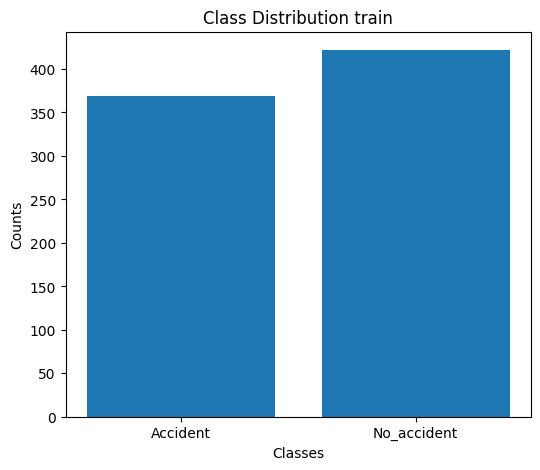

In [11]:
# Train class distribution
classes=["Accident","No_accident"]
counts=[train_accident,train_no_accident]
plt.figure(figsize=(6,5))

plt.bar(classes,counts)
plt.title("Class Distribution train")
plt.xlabel("Classes")
plt.ylabel("Counts")
plt.show()

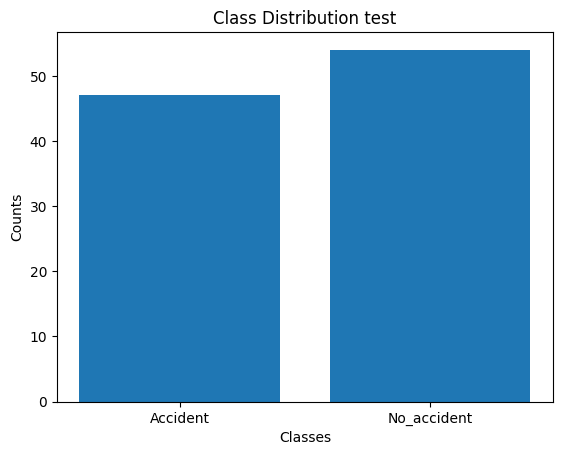

In [12]:
# test class distribution

classes=["Accident","No_accident"]
counts=[test_accident,test_no_accident]
plt.bar(classes,counts)
plt.title("Class Distribution test")
plt.xlabel("Classes")
plt.ylabel("Counts")
plt.show()

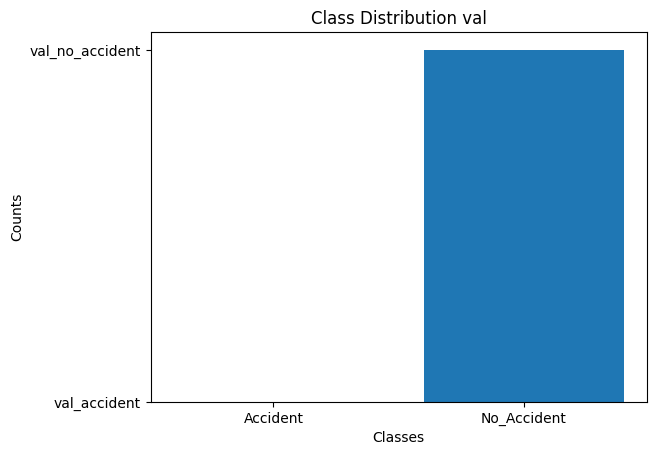

In [13]:
# validation class distribution

classes=["Accident","No_Accident"]
counts=["val_accident","val_no_accident"]
plt.bar(classes,counts)
plt.title("Class Distribution val")
plt.xlabel("Classes")
plt.ylabel("Counts")
plt.show()

Sample Visual Images of accident and no accident

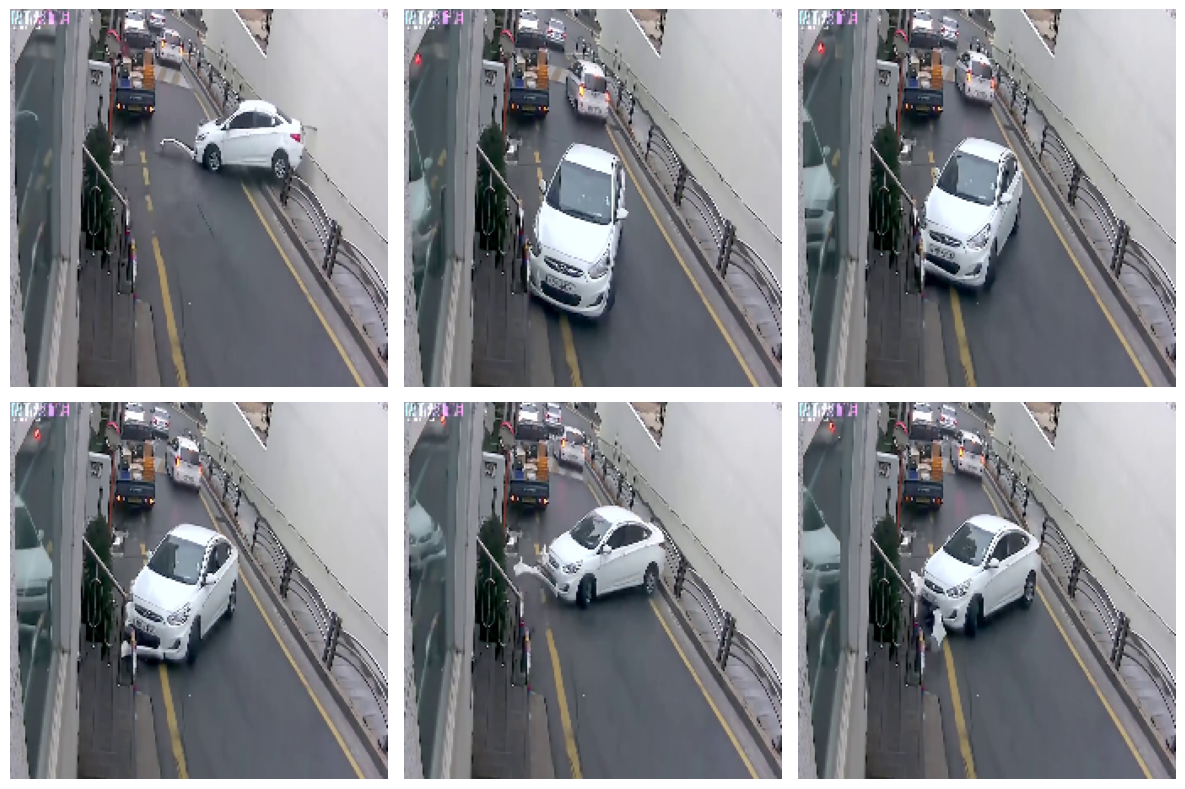

In [14]:
accident_images=os.listdir(os.path.join(train_path,"Accident"))

plt.figure(figsize=(12,8))

for i in range(6):
  image_path=os.path.join(train_path,"Accident",accident_images[i])

  # Use load_img from tensorflow.keras.preprocessing.image
  img=load_img(image_path,target_size=(224,224))

  plt.subplot(2,3,i+1)
  plt.imshow(img)
  plt.axis("off")
  plt.tight_layout() # Corrected typo: tight_plot should be tight_layout
plt.show()

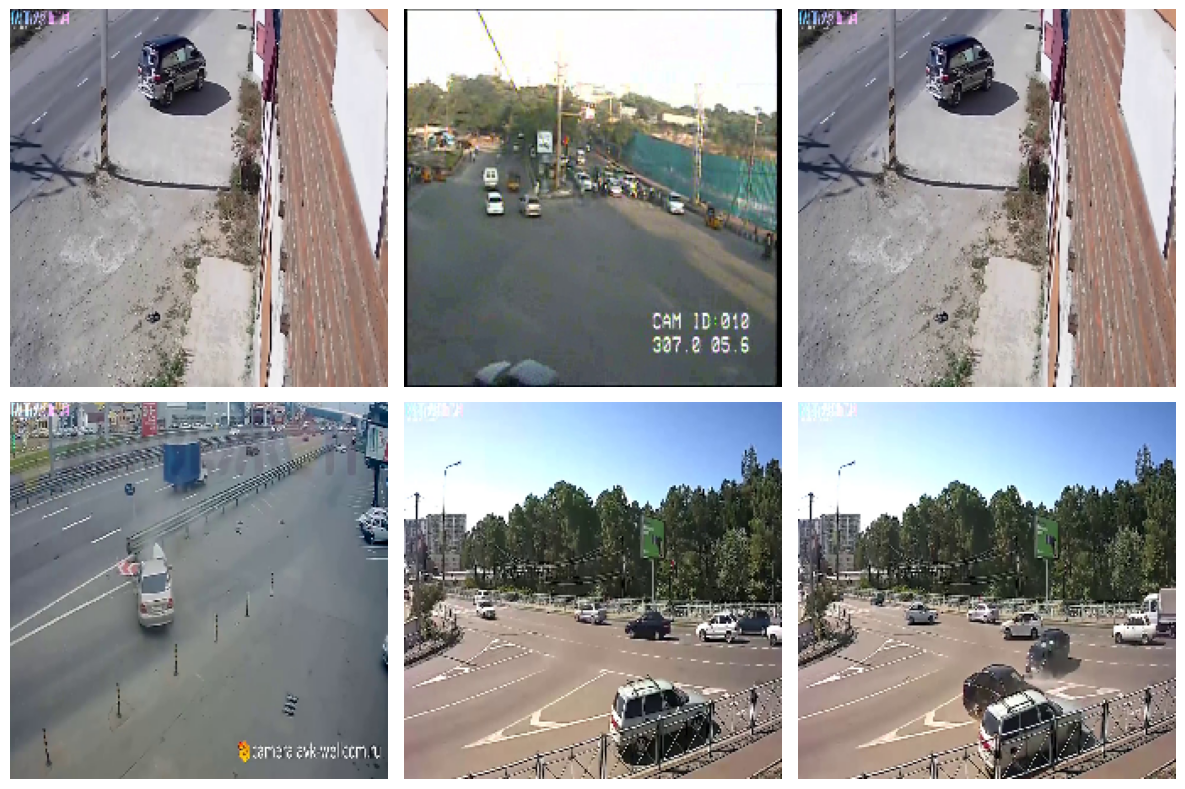

In [15]:
# sample images of no accident

no_accident=os.listdir(os.path.join(train_path,"Non Accident"))

plt.figure(figsize=(12,8))

for i in range(6):
  img_path=os.path.join(train_path,"Non Accident",no_accident[i])
  img=load_img(img_path,target_size=(224,224))
  plt.subplot(2,3,i+1)
  plt.imshow(img)
  plt.axis("off")
  plt.tight_layout()
plt.show()

# Checking The Image Shape

In [16]:
img_shape=[]

for class_name in ['Accident',"Non Accident"]:
  class_path=os.path.join(train_path,class_name)

  images=os.listdir(class_path)

  for image_name in images[:20]:
    image_path=os.path.join(class_path,image_name)
    img=load_img(image_path)
    img_array=img_to_array(img)
    img_shape.append((class_name,img_array.shape))
print(img_shape)

[('Accident', (720, 1280, 3)), ('Accident', (720, 1280, 3)), ('Accident', (720, 1280, 3)), ('Accident', (720, 1280, 3)), ('Accident', (720, 1280, 3)), ('Accident', (720, 1280, 3)), ('Accident', (720, 1280, 3)), ('Accident', (720, 1280, 3)), ('Accident', (720, 1280, 3)), ('Accident', (720, 1280, 3)), ('Accident', (576, 720, 3)), ('Accident', (576, 720, 3)), ('Accident', (576, 720, 3)), ('Accident', (576, 720, 3)), ('Accident', (720, 1280, 3)), ('Accident', (576, 720, 3)), ('Accident', (576, 720, 3)), ('Accident', (720, 1280, 3)), ('Accident', (576, 720, 3)), ('Accident', (720, 1280, 3)), ('Non Accident', (720, 1280, 3)), ('Non Accident', (576, 720, 3)), ('Non Accident', (720, 1280, 3)), ('Non Accident', (720, 1280, 3)), ('Non Accident', (720, 1280, 3)), ('Non Accident', (720, 1280, 3)), ('Non Accident', (720, 1280, 3)), ('Non Accident', (720, 1280, 3)), ('Non Accident', (576, 720, 3)), ('Non Accident', (720, 1280, 3)), ('Non Accident', (576, 720, 3)), ('Non Accident', (720, 1280, 3)), (

# **Width and Height Distribution**

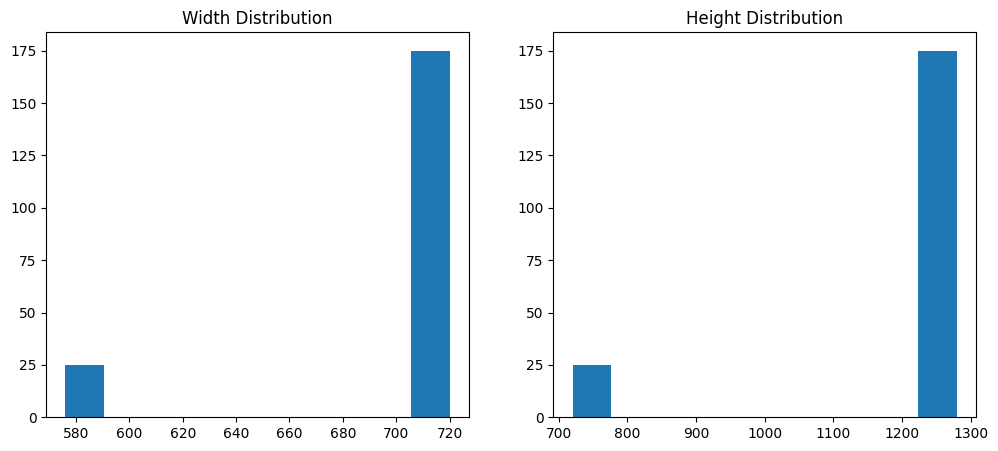

In [17]:
width=[]
height=[]

for class_name in ["Accident", "Non Accident"]:
  class_path=os.path.join(train_path,class_name)
  images=os.listdir(class_path)

  for image_name in images[:100]:
    img_path=os.path.join(class_path,image_name)
    img=load_img(img_path)
    img_array=img_to_array(img)
    width.append(img_array.shape[0])
    height.append(img_array.shape[1])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(width)
plt.title("Width Distribution")
plt.subplot(1,2,2)
plt.hist(height)
plt.title("Height Distribution")

plt.show()


# Checking for Corrupted Images

In [18]:
bad_images=[]

for class_name in ["Accident","Non Accident"]:
  class_path=os.path.join(train_path,class_name)

  for image_name in os.listdir(class_path):
    try:
      image_path=os.path.join(class_path,image_name)
      image=load_img(image_path)

    except:
      bad_images.append(image_path)

print("Corrupted_images",len(bad_images))


Corrupted_images 0


# Pixel Value Analysis

In [19]:
sample_image=os.listdir(os.path.join(train_path,'Accident'))[0]
img_path=os.path.join(train_path,"Accident",sample_image)

img_load=load_img(img_path)

img_array=img_to_array(img_load)

print("Minimum Pixel",img_array.min())
print("Maximum_Pixel",img_array.max())


Minimum Pixel 0.0
Maximum_Pixel 255.0


# Image Augumentation Visualization

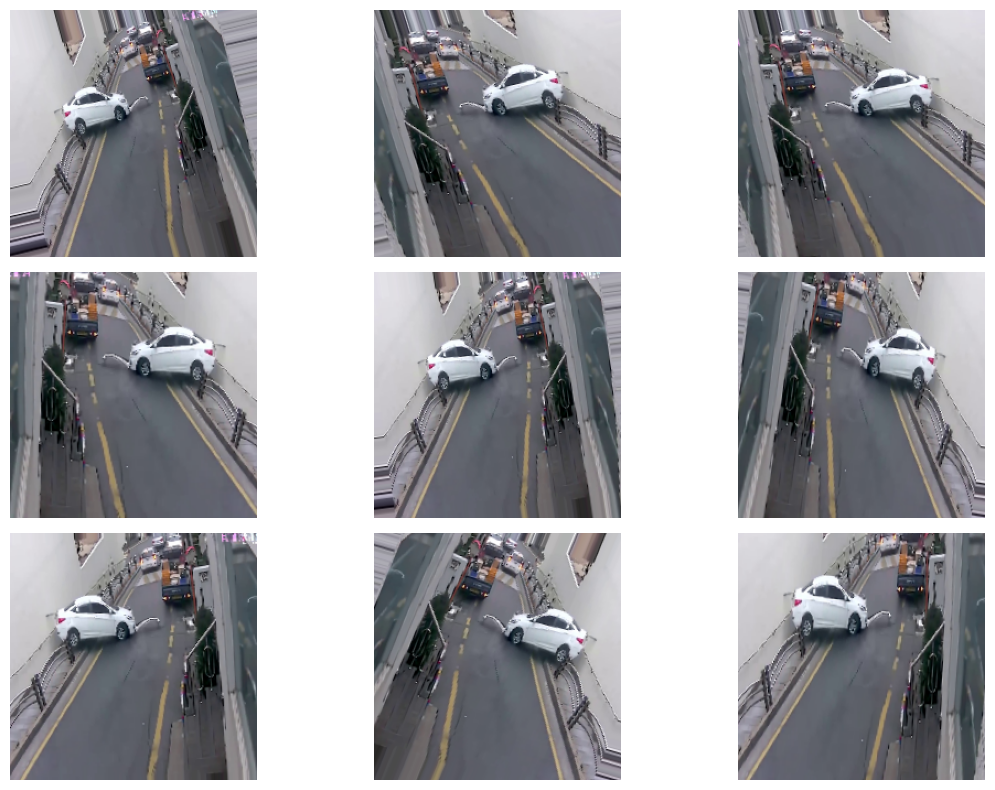

In [20]:
# Createing rule for Image Augumentation
datagen=ImageDataGenerator(rotation_range=20,zoom_range=0.2,horizontal_flip=True)

# Image
img=load_img(img_path,target_size=(224,224))
image_array=img_to_array(img)
x=np.expand_dims(image_array,axis=0)

plt.figure(figsize=(12,8))

i=0

for batch in datagen.flow(x,batch_size=1):
  plt.subplot(3,3,i+1)
  plt.imshow(batch[0].astype("uint8"))
  plt.axis("off")
  i+=1
  if i==9:
    break
plt.tight_layout()
plt.show()



# Tensor flow data generator  before training

In [21]:
# @title Default title text
# just to see how this tensor flow data generator works

#train_datagen=ImageDataGenerator(rescale=1./255,rotation_range=20,zoom_range=0.2,horizontal_flip=True)

#val_datagen=ImageDataGenerator(rescale=1./255)

#train_generator=train_datagen.flow_from_directory(train_path,target_size=(224,224),batch_size=32,class_mode='binary')

#val_generator=val_datagen.flow_from_directory(val_path,target_size=(224,224),batch_size=32,class_mode='binary')#

# Visualize Batch From Generator

In [22]:
#images,labels=next(train_generator)
#plt.figure(figsize=(12,8))
#i = 0
#for i in range(15):
  #plt.subplot(3,5,i+1)
  #plt.imshow(images[i])
  #plt.title(labels[i])
  #plt.axis("off")

  #if i==9:
    #break
#plt.tight_layout()
#plt.show()

In [24]:
!pip install mlflow --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

#**Modelling Model 1**

In [25]:
# import all necessary libraraies
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D

import mlflow
import mlflow.tensorflow





In [26]:
# enable  mlflow auto log and set expirement
mlflow.set_experiment("CNN_ACCIDENT_CLASSIFICATION")

2026/05/24 15:16:04 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/24 15:16:05 INFO mlflow.store.db.utils: Updating database tables
2026/05/24 15:16:06 INFO mlflow.tracking.fluent: Experiment with name 'CNN_ACCIDENT_CLASSIFICATION' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1779635766794, experiment_id='1', last_update_time=1779635766794, lifecycle_stage='active', name='CNN_ACCIDENT_CLASSIFICATION', tags={}, trace_location=None, workspace='default'>

In [27]:
# set exporemt using mlfow
mlflow.tensorflow.autolog(),

(None,)

In [28]:
# Create Data Generator

train_datagen=ImageDataGenerator(rescale=1./255,rotation_range=20,zoom_range=0.2,horizontal_flip=True)

val_datagen=ImageDataGenerator(rescale=1./255)

test_datagen=ImageDataGenerator(rescale=1./255)

In [29]:
# Lets Load Dataset in from directory and aplly generator
train_generator=train_datagen.flow_from_directory(train_path,target_size=(224,224),batch_size=32,class_mode='binary')

val_generator=val_datagen.flow_from_directory(val_path,target_size=(224,224),batch_size=32,class_mode='binary')

test_generator=test_datagen.flow_from_directory(test_path,target_size=(224,224),batch_size=32,class_mode='binary',shuffle=False)

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [30]:
with mlflow.start_run():
  FILTER_1=32
  FILTER_2=64
  FILTER_3=128

  DENSE_UNITS=128
  DROPOUT_RATE=0.5
  EPOCHS=20
  LEARNING_RATE=0.0001



In [31]:
  model= Sequential()

  # First Layer
  model.add(Conv2D(filters=FILTER_1,kernel_size=(3,3),activation='relu',padding='same',input_shape=(224,224,3)))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(0.25))

  # SECOND CONVO LAYER
  model.add(Conv2D(filters=FILTER_2,kernel_size=(3,3),activation='relu',padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(0.25))

  #Third CNN Block
  model.add(Conv2D(filters=FILTER_3,kernel_size=(3,3),activation='relu',padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(0.25))


  # Layer Flatten
  model.add(GlobalAveragePooling2D())

  # Dense Layer
  model.add(Dense(DENSE_UNITS,activation='relu'))

  # Dropout
  model.add(Dropout(DROPOUT_RATE))

  #Output Layer
  model.add(Dense(1,activation='sigmoid'))

  # summery
  model.summary()

  # model compilation
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),loss='binary_crossentropy',metrics=['accuracy'])

  # Early_stop
  early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

  # reduce lr
  reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=3,verbose=1)

  # model checkpoint
  model_checkpoint=ModelCheckpoint('best_model.h5',monitor='val_accuracy',save_best_only=True)

  # Training CNN Model
  history=model.fit(train_generator,validation_data=val_generator,epochs=EPOCHS,callbacks=[early_stop,reduce_lr,model_checkpoint])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

...

2026/05/24 15:16:10 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8276abe0730b46528171ab1e55833722', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/05/24 15:16:12 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2026/05/24 15:16:12 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.5372 - loss: 0.8230

25/25 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.5221 - loss: 0.7967 - val_accuracy: 0.5306 - val_loss: 0.6930 - learning_rate: 1.0000e-04
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - accuracy: 0.6137 - loss: 0.7300

25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 775ms/step - accuracy: 0.5904 - loss: 0.7263 - val_accuracy: 0.5306 - val_loss: 0.6921 - learning_rate: 1.0000e-04
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 719ms/step - accuracy: 0.5550 - loss: 0.7217 - val_accuracy: 0.5306 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 728ms/step - accuracy: 0.5487 - loss: 0.7063 - val_accuracy: 0.5306 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.5743 - loss: 0.6944
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 746ms/step - accuracy: 0.5879 - loss: 0.6857 - val_accuracy: 0.5306 - val_loss: 0.6958 - learning_rate: 1.0000e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 753ms/step - accuracy: 0.5563 - loss: 0.7102 - val_accuracy: 0.5306 - val_loss: 0.6981 - learning_rate: 2.0000e-05
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 746ms/step - accuracy: 0.5765 - 

2026/05/24 15:20:45 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2026/05/24 15:20:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 15:20:45 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [32]:
  # MODEL EVALUATION
  test_loss,test_accuracy=model.evaluate(test_generator)

  print("Test_loss",test_loss)
  print("test_accuracy",test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5300 - loss: 0.6908
Test_loss 0.6907574534416199
test_accuracy 0.5299999713897705


In [46]:
%cd /content/drive/MyDrive/CNN_ACCIDENT_DATASET/

/content/drive/MyDrive/CNN_ACCIDENT_DATASET


In [54]:
!rm -rf .git

In [55]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/CNN_ACCIDENT_DATASET/.git/
